In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings


warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

In [4]:
df = pd.read_csv("../data/cleaned/zomato_cleaned.csv",encoding = 'latin-1')
print(df.shape)
df.head()

(41202, 12)


,address,name,online_order,book_table,rate,votes,location,rest_type,cuisines,approx_cost(for two people),listed_in(type),listed_in(city)
0,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1,775,Banashankari,Casual Dining,"North Indian, Mughlai, Chinese",800.0,Buffet,Banashankari
1,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1,787,Banashankari,Casual Dining,"Chinese, North Indian, Thai",800.0,Buffet,Banashankari
2,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8,918,Banashankari,"Cafe, Casual Dining","Cafe, Mexican, Italian",800.0,Buffet,Banashankari
3,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7,88,Banashankari,Quick Bites,"South Indian, North Indian",300.0,Buffet,Banashankari
4,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8,166,Basavanagudi,Casual Dining,"North Indian, Rajasthani",600.0,Buffet,Banashankari


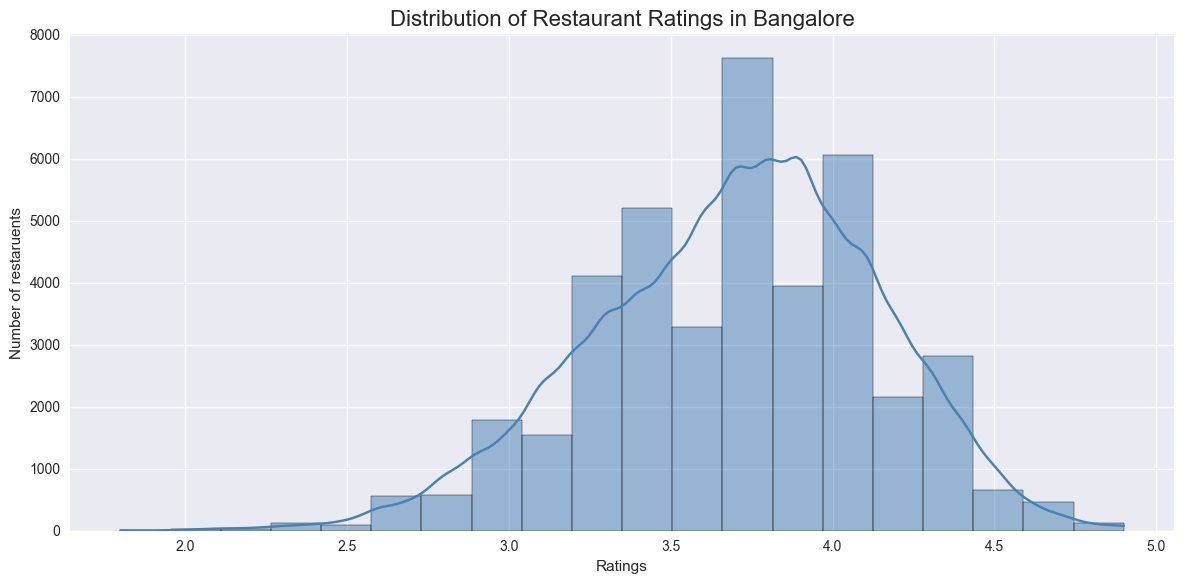

In [6]:
# checking the distribution of ratings of restaruents
sns.histplot(df['rate'],bins = 20, kde = True, color = 'steelblue')
plt.title('Distribution of Restaurant Ratings in Bangalore', fontsize=16)
plt.xlabel("Ratings")
plt.ylabel("Number of restaruents")
plt.tight_layout()
plt.show()

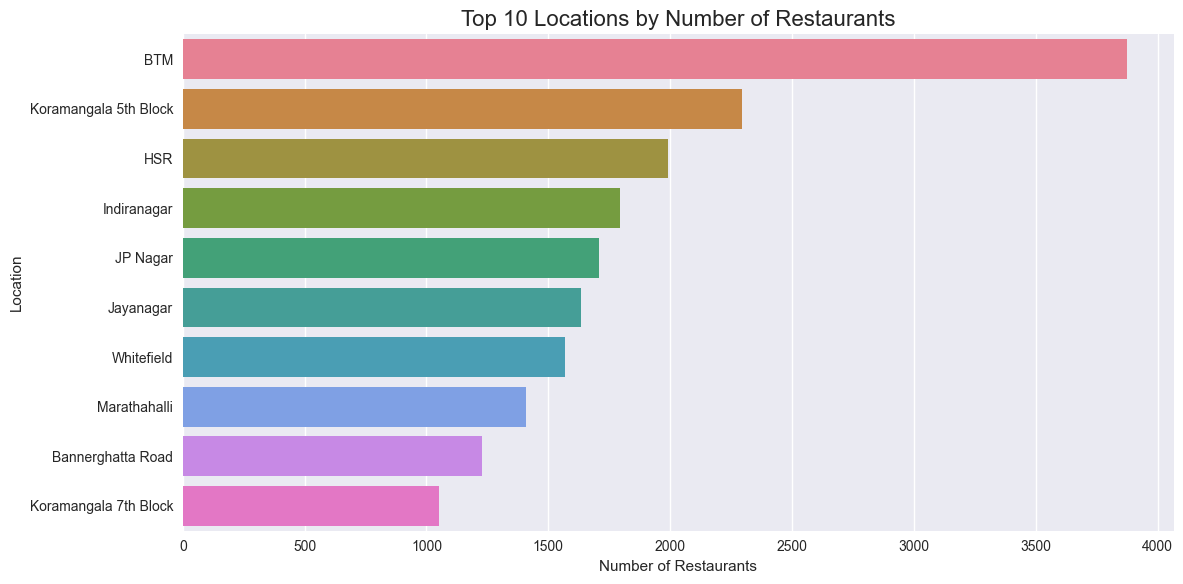

In [15]:
location_count = df['location'].value_counts().head(10)
sns.barplot(x = location_count.values,y = location_count.index,palette = 'husl')
plt.title('Top 10 Locations by Number of Restaurants',fontsize=16)
plt.xlabel('Number of Restaurants')
plt.ylabel('Location')
plt.tight_layout()
plt.show()

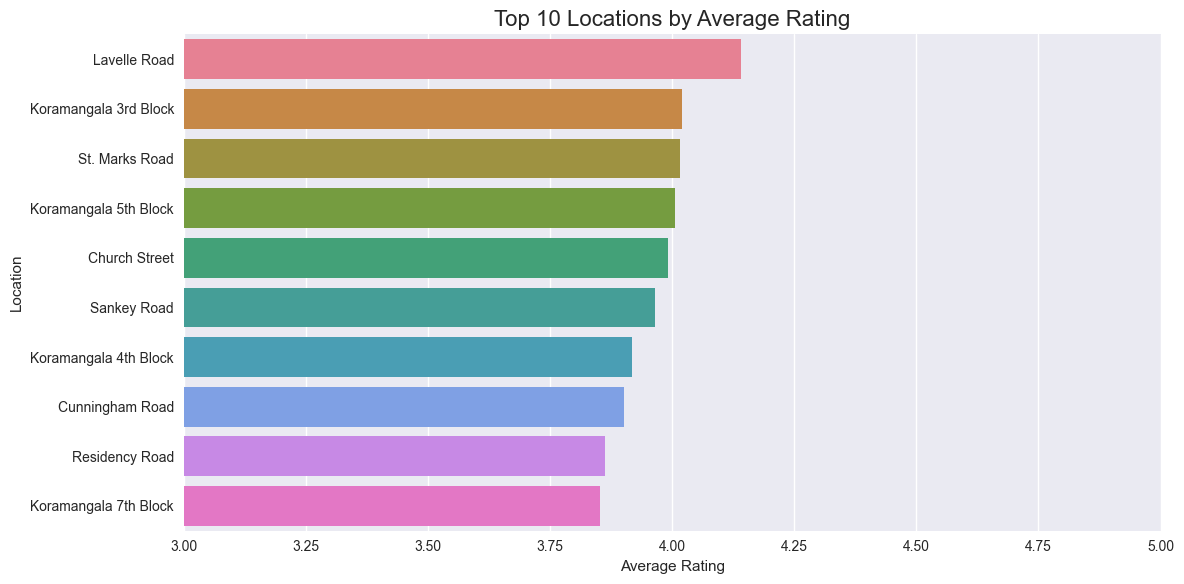

In [14]:
#Relationship between restaruent count(by area) and ratings
avg_rating_loc = df.groupby('location')['rate'].mean().sort_values(ascending = False).head(10)
sns.barplot(x = avg_rating_loc.values, y = avg_rating_loc.index,palette = 'husl')
plt.title('Top 10 Locations by Average Rating', fontsize=16)
plt.xlabel('Average Rating')
plt.ylabel('Location')
plt.xlim(3, 5)
plt.tight_layout()
plt.show()

In [17]:
print('Average rating of restaruents Lavelle Road',df[df['location'] == 'Lavelle Road']['rate'].mean().round(3))
print('Average cost of restaurants in Lavelle Road',df[df['location'] == 'Lavelle Road']['approx_cost(for two people)'].mean().round(3))
print('Average rating of restaruents BTM',df[df['location'] == 'BTM']['rate'].mean().round(3))
print('Average cost of restaurants in BTM',df[df['location'] == 'BTM']['approx_cost(for two people)'].mean().round(3))

Average rating of restaruents Lavelle Road 4.14
Average cost of restaurants in Lavelle Road 1365.021
Average rating of restaruents BTM 3.572
Average cost of restaurants in BTM 418.206


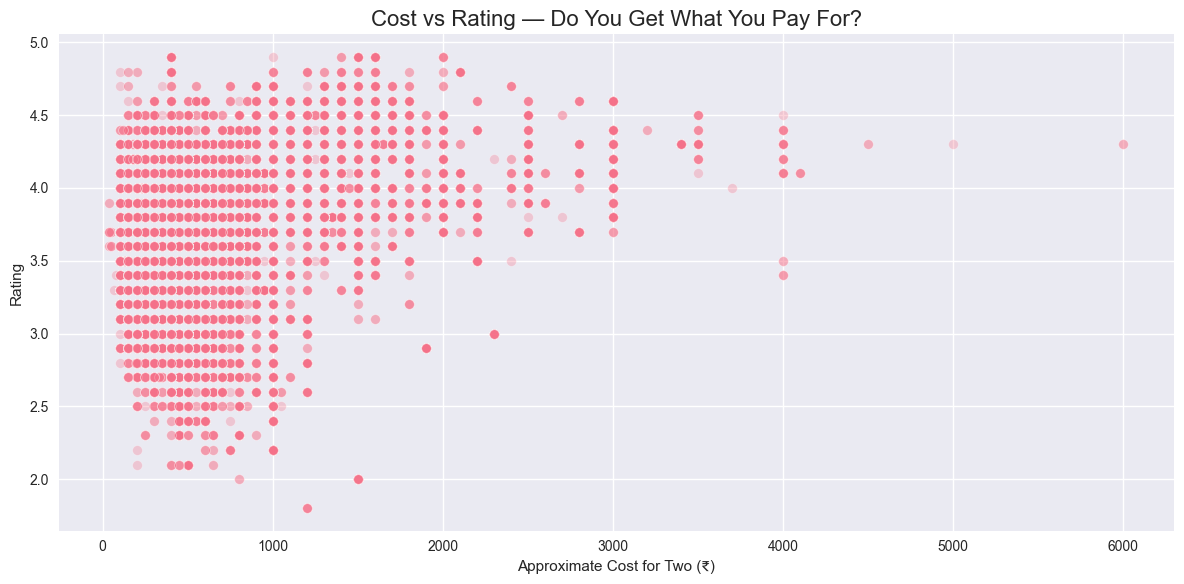

In [13]:
#Cost vs Rating Scatter Plot
sns.scatterplot(data=df,x='approx_cost(for two people)',y='rate',alpha = 0.3,palette = 'husl')
plt.title('Cost vs Rating — Do You Get What You Pay For?', fontsize=16)
plt.xlabel('Approximate Cost for Two (₹)')
plt.ylabel('Rating')
plt.tight_layout()
plt.show()

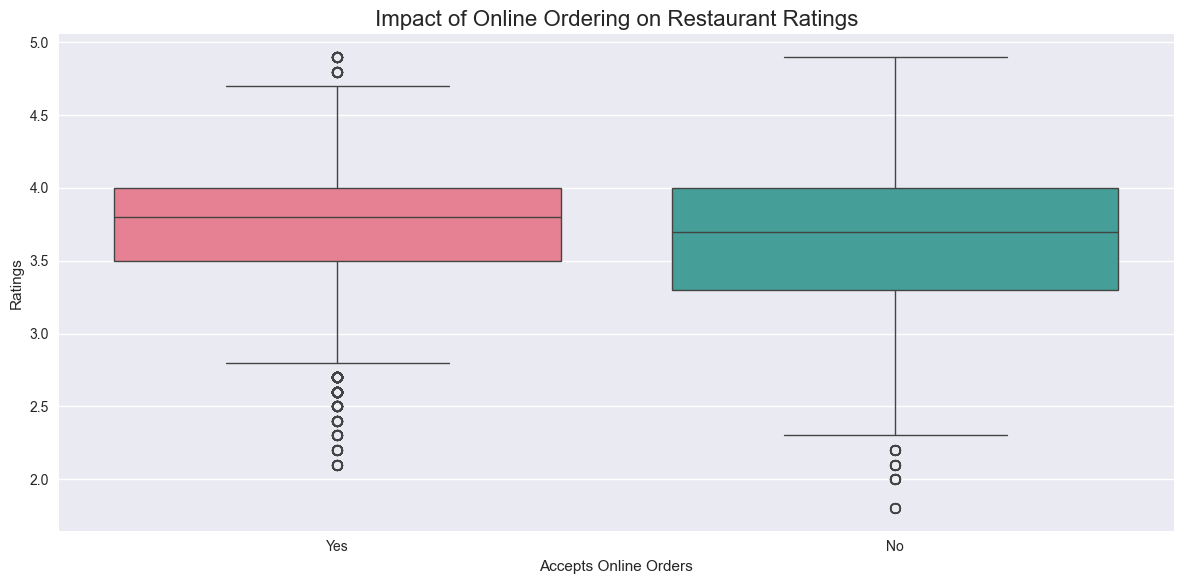

In [6]:
#relationship between Online Order and Rating
sns.boxplot(data=df,x ='online_order',y = 'rate',palette = 'husl')
plt.title('Impact of Online Ordering on Restaurant Ratings', fontsize=16)
plt.xlabel('Accepts Online Orders')
plt.ylabel('Ratings')
plt.tight_layout()
plt.show()

In [8]:
print("median of the ratings for restaruents with online_orders availability: ",df[df['online_order'] == 'Yes']['rate'].median())
print("median of the ratings for restaruents with no online_orders availability: ",df[df['online_order'] == 'No']['rate'].median())

median of the ratings for restaruents with online_orders availability:  3.8
median of the ratings for restaruents with no online_orders availability:  3.7


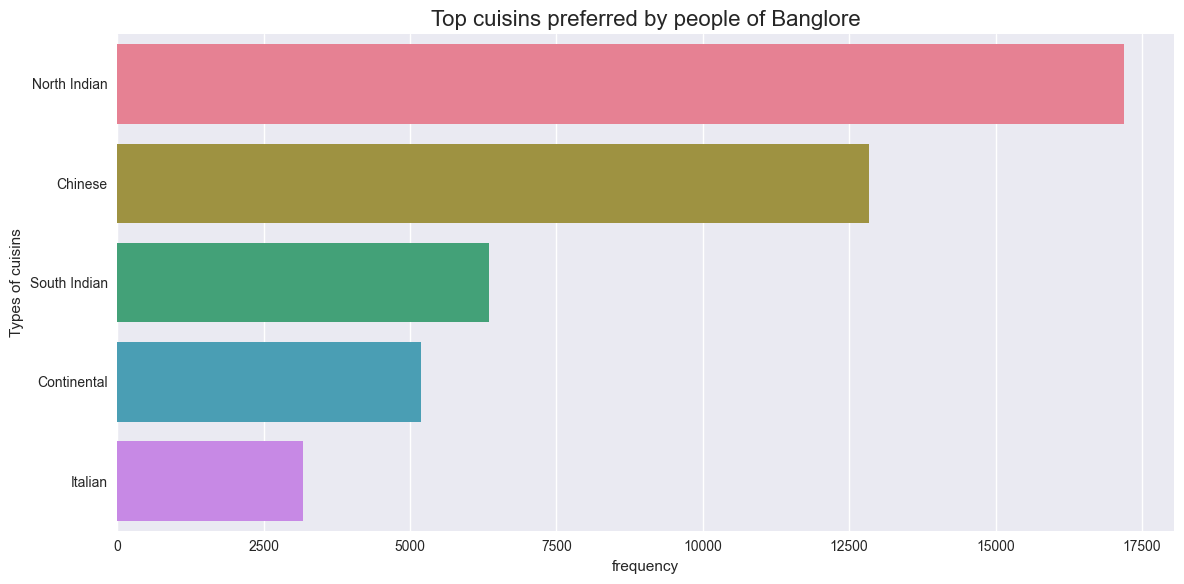

In [12]:
#Dominance of cuisine in Banglore
cuisine_split = df['cuisines'].str.split(',').explode().str.strip()
cuisine_count = cuisine_split.value_counts().head(10)
act_cui = ['North Indian','Chinese','South Indian','Continental','Italian']
cuisine_count = cuisine_count[act_cui]
sns.barplot(x = cuisine_count.values,y = cuisine_count.index,palette = 'husl')
plt.title('Top cuisins preferred by people of Banglore', fontsize=16)
plt.xlabel('frequency')
plt.ylabel('Types of cuisins')
plt.tight_layout()
plt.show()

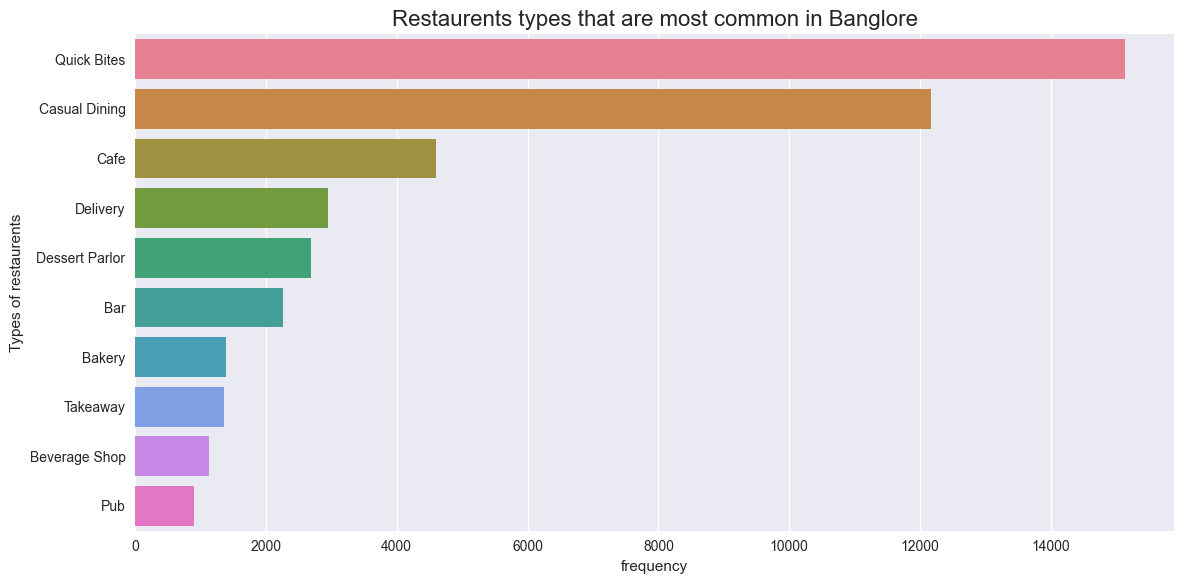

In [17]:
#Restaurents types that are common in Banglore
res_split = df['rest_type'].str.split(',').explode().str.strip()
restype_count = res_split.value_counts().head(10)
sns.barplot(x = restype_count.values,y = restype_count.index,palette = 'husl')
plt.title('Restaurents types that are most common in Banglore',fontsize = 16)
plt.xlabel('frequency')
plt.ylabel('Types of restaurents')
plt.tight_layout()
plt.show()

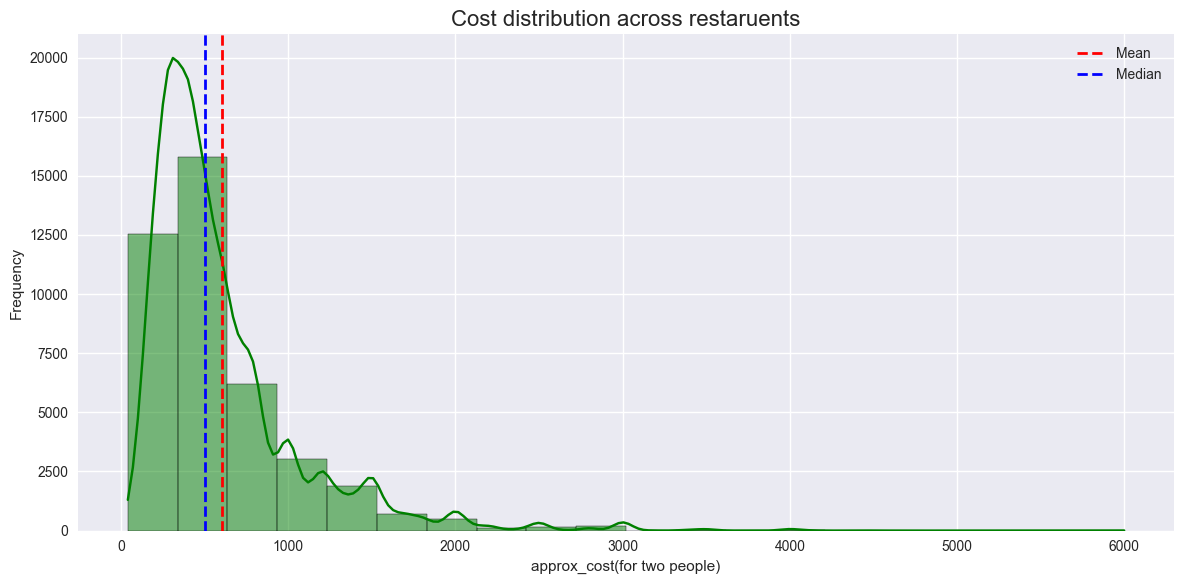

In [24]:
#cost distribution across restaruents
sns.histplot(df['approx_cost(for two people)'],bins = 20,kde = True, color = 'green')
plt.axvline(df['approx_cost(for two people)'].mean(),color='red', linestyle='--', linewidth=2, label='Mean')
plt.axvline(df['approx_cost(for two people)'].median(),color='blue', linestyle='--', linewidth=2, label='Median')
plt.title('Cost distribution across restaruents',fontsize = 16)
plt.xlabel('approx_cost(for two people)')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

In [26]:
#actual difference between mean and median price
print(f"Mean cost:   ₹{df['approx_cost(for two people)'].mean():.2f}")
print(f"Median cost: ₹{df['approx_cost(for two people)'].median():.2f}")
print(f"Difference:  ₹{df['approx_cost(for two people)'].mean() - df['approx_cost(for two people)'].median():.2f}")

Mean cost:   ₹603.50
Median cost: ₹500.00
Difference:  ₹103.50


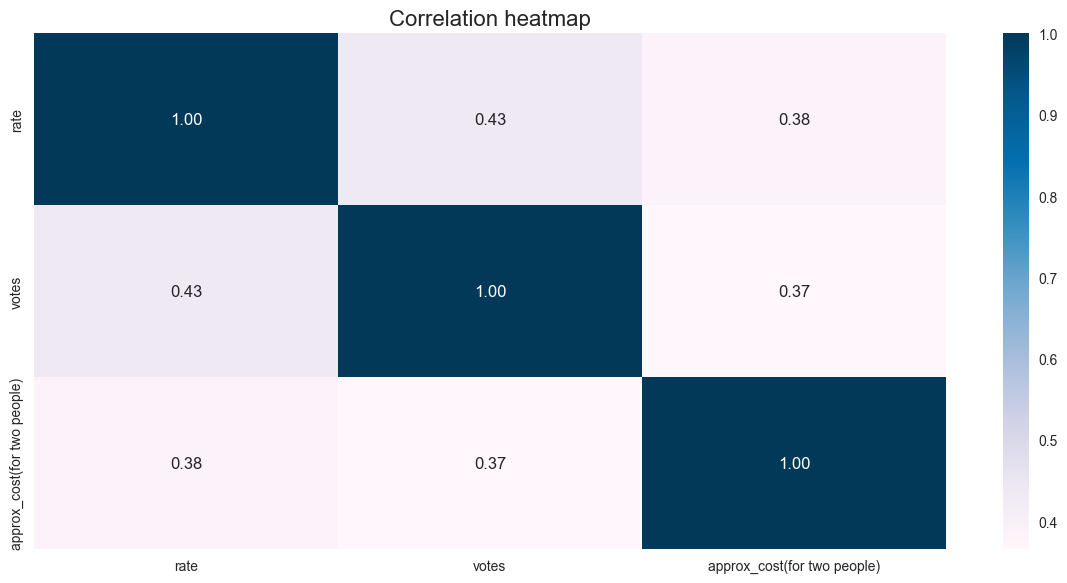

In [33]:
#correlation heatmap
num_col = df.select_dtypes(include='number').columns
sns.heatmap(df[num_col].corr(),annot = True,fmt = '.2f',cmap = 'PuBu')
plt.title('Correlation heatmap',fontsize = 16)
plt.tight_layout()
plt.show()

### Key Business Insights

## Most Surprising Finding
Cost and rating have only a weak correlation (0.38) in Bangalore's 
restaurant scene — meaning expensive restaurants are NOT guaranteed 
to be better rated. A ₹300 restaurant can easily outrate a ₹2,000 one.

## Business Recommendation
If opening a new restaurant in Bangalore:
- **Location** → JP Nagar, Jayanagar or Indiranagar
  (good footfall, less saturated than BTM)
- **Cuisine** → North Indian + Chinese 
  (top 2 most popular cuisines)
- **Online Ordering** → Yes 
  (online restaurants show more consistent ratings)
- **Price Range** → ₹300-₹1,500 for two 
  (sweet spot — good quality without premium pricing)

## Additional Data Needed
- Individual dish prices (not just cost for two)
- Complete dish preference data
- Separate ratings for food, service and ambience
- Time based ordering patterns
- Customer demographic data
- Competitor pricing in same area